In [1]:
print("hi")

hi


In [3]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Suppress scientific library warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
FS = 700
WINDOW_SEC = 30 
STEP_SEC = 5  # 5-second step = 25s overlap
SAMPLES_PER_WINDOW = FS * WINDOW_SEC
SAMPLES_PER_STEP = FS * STEP_SEC

# Subject list (Excluding S12 as is standard for WESAD)
SUBJECT_IDS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
DATA_PATH = 'WESAD/' 

all_windows_data = []

print(f"Starting extraction: {WINDOW_SEC}s windows, {STEP_SEC}s steps.")

# --- 2. EXTRACTION LOOP WITH TQDM ---
for subject in tqdm(SUBJECT_IDS, desc="Processing Subjects"):
    file_path = os.path.join(DATA_PATH, subject, f'{subject}.pkl')
    if not os.path.exists(file_path):
        continue
        
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
        
    labels = data['label']
    ecg_raw = data['signal']['chest']['ECG'].flatten()
    eda_raw = data['signal']['chest']['EDA'].flatten()
    
    for target_label in [1, 2]: # 1=Baseline, 2=Stress
        indices = np.where(labels == target_label)[0]
        
        for i in range(0, len(indices) - SAMPLES_PER_WINDOW, SAMPLES_PER_STEP):
            start = indices[i]
            end = start + SAMPLES_PER_WINDOW
            
            try:
                w_ecg = ecg_raw[start:end]
                w_eda = eda_raw[start:end]
                
                # ECG Features
                ecg_signals, _ = nk.ecg_process(w_ecg, sampling_rate=FS)
                hrv = nk.hrv(ecg_signals, sampling_rate=FS)
                
                # EDA Features
                eda_signals, _ = nk.eda_process(w_eda, sampling_rate=FS)
                eda_f = nk.eda_analyze(eda_signals, sampling_rate=FS)
                
                # Combine
                combined = pd.concat([hrv, eda_f], axis=1)
                combined['subject_id'] = subject
                combined['label'] = target_label
                combined['ECG_Rate_Mean'] = ecg_signals["ECG_Rate"].mean()
                
                all_windows_data.append(combined)
            except:
                continue

# --- 3. CLEANING & NORMALIZATION ---
df = pd.concat(all_windows_data, ignore_index=True)
df = df.dropna(axis=1, thresh=int(0.5 * len(df)))
df = df.fillna(df.mean())

# Store raw features for visualization before normalization
df_raw = df.copy()

features_to_norm = [c for c in df.columns if c not in ['subject_id', 'label']]
for subject in SUBJECT_IDS:
    mask = df['subject_id'] == subject
    if mask.any():
        for col in features_to_norm:
            col_mean = df.loc[mask, col].mean()
            col_std = df.loc[mask, col].std()
            if col_std > 0:
                df.loc[mask, col] = (df.loc[mask, col] - col_mean) / col_std
            else:
                df.loc[mask, col] = 0.0

df.to_csv('wesad_final_normalized_features.csv', index=False)

# --- 4. VISUALIZATION SECTION ---

# Set style
sns.set_theme(style="whitegrid")

# Plot A: Data Summary (Numerizing the data)
plt.figure(figsize=(12, 6))
summary_data = df.groupby(['subject_id', 'label']).size().reset_index(name='counts')
summary_data['label'] = summary_data['label'].map({1: 'Baseline', 2: 'Stress'})

sns.barplot(data=summary_data, x='subject_id', y='counts', hue='label')
plt.title('Sample Distribution per Subject (30s Windows, 5s Step)')
plt.ylabel('Number of Windows')
plt.xlabel('Subject ID')
plt.savefig('data_summary.png')
plt.close()

# Plot B: Physiology Comparison for Subject S2 (Key Features)
s2_data = df_raw[df_raw['subject_id'] == 'S2']
s2_data['label'] = s2_data['label'].map({1: 'Baseline', 2: 'Stress'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSSD Comparison
sns.boxplot(x='label', y='HRV_RMSSD', data=s2_data, ax=ax1, palette='Set2')
ax1.set_title('S2: HRV RMSSD (Parasympathetic Activity)')
ax1.set_ylabel(r'RMSSD (ms)')

# SCR Amplitude Comparison
sns.boxplot(x='label', y='SCR_Peaks_Amplitude_Mean', data=s2_data, ax=ax2, palette='Set2')
ax2.set_title(r'S2: SCR Amplitude (Sympathetic Arousal)')
ax2.set_ylabel(r'Amplitude ($\mu S$)')

plt.tight_layout()
plt.savefig('subject_s2_comparison.png')
plt.close()

print("Process finished. CSV saved and plots generated.")

Starting extraction: 30s windows, 5s steps.


Processing Subjects: 100%|██████████| 15/15 [23:22<00:00, 93.52s/it] 


TypeError: Cannot perform reduction 'mean' with string dtype

In [4]:
# 1. Re-create the dataframe from the list still in memory
df = pd.concat(all_windows_data, ignore_index=True)

# 2. Drop columns that are mostly empty
df = df.dropna(axis=1, thresh=int(0.5 * len(df)))

# 3. FIX: Only calculate mean for numeric columns
df = df.fillna(df.mean(numeric_only=True))

# 4. Proceed with Normalization
features_to_norm = [c for c in df.columns if c not in ['subject_id', 'label']]

for subject in SUBJECT_IDS:
    mask = df['subject_id'] == subject
    if mask.any():
        for col in features_to_norm:
            col_mean = df.loc[mask, col].mean()
            col_std = df.loc[mask, col].std()
            if col_std > 0:
                df.loc[mask, col] = (df.loc[mask, col] - col_mean) / col_std
            else:
                df.loc[mask, col] = 0.0

# 5. Export
df.to_csv('wesad_final_normalized_features.csv', index=False)
print("Fix applied. CSV saved successfully.")

Fix applied. CSV saved successfully.


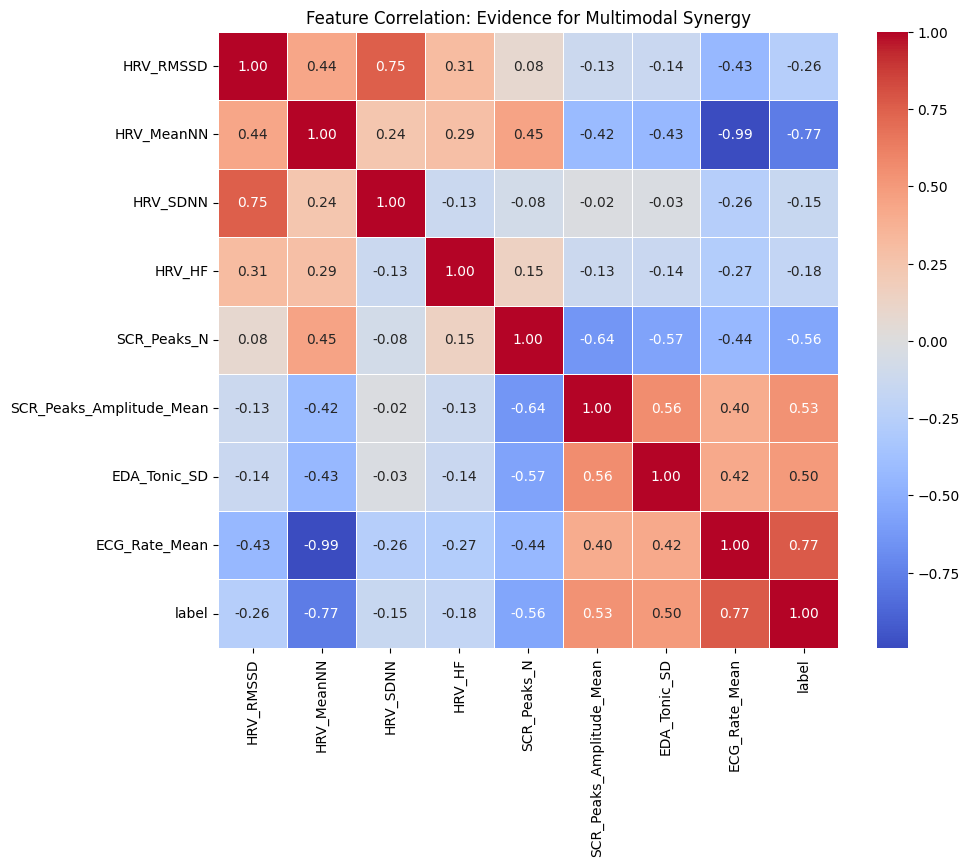

Calculating T-SNE visualization (sampling 1000 points for speed)...


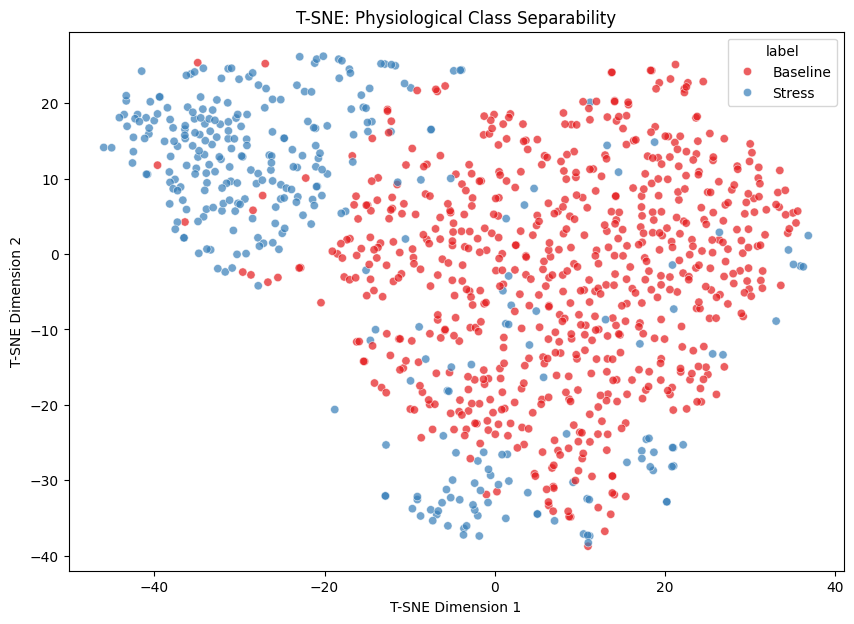

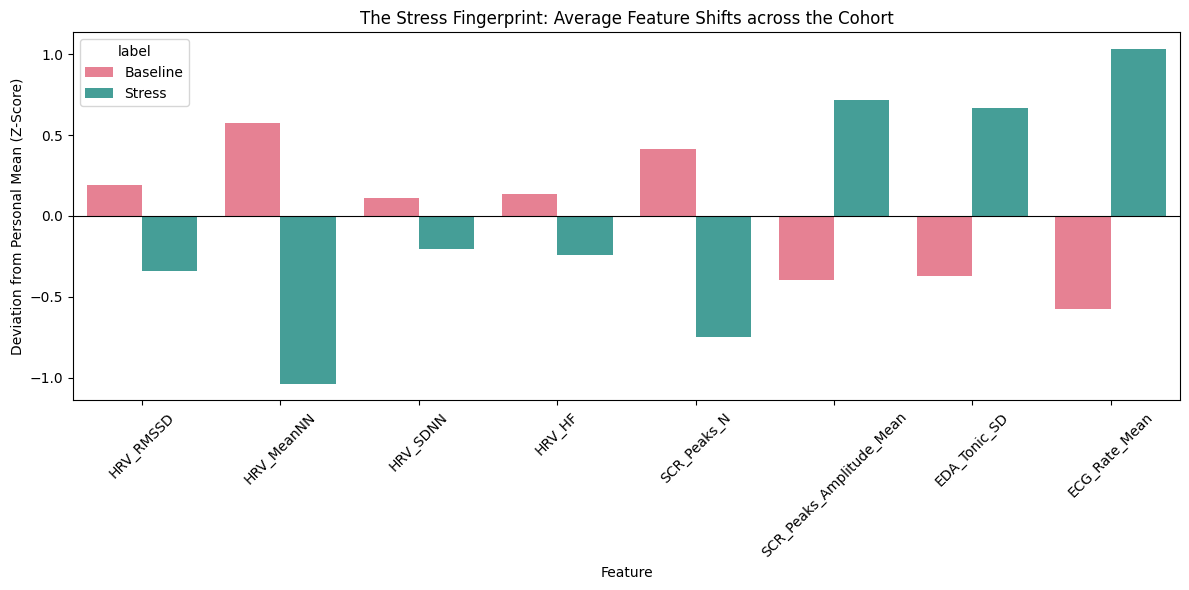

Advanced visualizations complete.


In [7]:
# --- SECTION 5: ADVANCED DATASET EXPLORATORY ANALYSIS ---
# This section provides high-level evidence for feature separability and sensor synergy.

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# 1. Feature Correlation Heatmap
# Purpose: Shows that heart and skin data provide different, non-redundant information.
key_features = [
    'HRV_RMSSD', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_HF', 
    'SCR_Peaks_N', 'SCR_Peaks_Amplitude_Mean', 
    'EDA_Tonic_SD', 'ECG_Rate_Mean', 'label'
]

plt.figure(figsize=(10, 8))
# Calculating correlation only for these representative features
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation: Evidence for Multimodal Synergy')
plt.savefig('advanced_feature_correlation.png')
plt.show()

# 2. T-SNE Manifold Visualization
# Purpose: To visualize the 77-dimensional data in 2D to see if 'Stress' and 'Baseline' cluster separately.
print("Calculating T-SNE visualization (sampling 1000 points for speed)...")

# Sample data for performance
df_sample = df.sample(n=min(1000, len(df)), random_state=42)
features_only = df_sample.drop(columns=['subject_id', 'label'])

# Version check for scikit-learn to handle parameter name changes
# n_iter was renamed to max_iter in newer versions
tsne_params = {
    'n_components': 2,
    'perplexity': 30,
    'random_state': 42
}

if hasattr(TSNE(), 'max_iter'):
    tsne_params['max_iter'] = 1000
else:
    tsne_params['n_iter'] = 1000

tsne = TSNE(**tsne_params)
tsne_results = tsne.fit_transform(features_only)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue=df_sample['label'].map({1: 'Baseline', 2: 'Stress'}),
    palette='Set1', alpha=0.7
)
plt.title('T-SNE: Physiological Class Separability')
plt.xlabel('T-SNE Dimension 1')
plt.ylabel('T-SNE Dimension 2')
plt.savefig('advanced_tsne_clustering.png')
plt.show()

# 3. Global Stress Fingerprint (Cohort-wide)
# Purpose: Shows exactly how many standard deviations (z) each signal moves during stress.
stress_profile = df.groupby('label')[key_features[:-1]].mean().reset_index()
stress_profile['label'] = stress_profile['label'].map({1: 'Baseline', 2: 'Stress'})

# Melt for the bar plot format
melted_profile = stress_profile.melt(id_vars='label', var_name='Feature', value_name='Z-Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_profile, x='Feature', y='Z-Score', hue='label', palette='husl')
plt.xticks(rotation=45)
plt.title('The Stress Fingerprint: Average Feature Shifts across the Cohort')
plt.ylabel('Deviation from Personal Mean (Z-Score)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('advanced_stress_fingerprint.png')
plt.show()

print("Advanced visualizations complete.")